Здесь будем строить ЭФР и гистрограммы для данных из дескриптора. 
При построении будем делить данные на различные классы, чтобы проанализировать распределения в зависимости от различных классов. В этой работе я решил проанализировать такие группировки:
1. Рынок (первичка, вторичка)
1. Тип квартиры (квартира, студия)
2. Гео. Для выполнения этой группировки я разбил все точки на 6 классов по терриореальному расположению. Классы выбраны рандомные, без какого-либо обсонования. Визуализация расположения расположения расположена в ячейке `[7]`.

Для начала я решил построить ЭФР для двух столбцов - площадь (area), этаж квартиры (floor).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
#df_clusters = pd.read_parquet("../data/geocoding/geocodes_checkpoint.parquet", engine='fastparquet')

#print(df_clusters["latitude"].isna().mean() * 100, "%")

# Получил 77 процентов пропусков, поэтому геокодирование пока опустим

In [3]:
import os
path = "../data/processed/v2/housing_residential_processed.parquet"
print("Файл существует:", os.path.exists(path))
if os.path.exists(path):
    print("Размер файла:", os.path.getsize(path), "байт")
    # Если размер очень мал (например, < 100 байт), файл почти наверняка битый.

Файл существует: True
Размер файла: 31144832 байт


In [4]:
df = pd.read_parquet("../data/processed/v2/housing_residential_processed.parquet")
data = df.copy()

print(df.columns)
print(f"Всего записей: {len(df)}")

df_clean = df.dropna(subset=["longitude", "latitude"]).copy()

Index(['address', 'longitude', 'latitude', 'area', 'room_count', 'floor',
       'floor_count', 'market_type', 'flat_type', 'ceiling_height',
       'build_year', 'balcony', 'price', 'price_per_square_meter', 'date'],
      dtype='str')
Всего записей: 1336403


In [5]:
coords = df_clean[["longitude", "latitude"]].values

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

n_clusters = 6  # количество класстеров
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(coords_scaled)

df_clean["cluster_zone"] = cluster_labels

print(df_clean["cluster_zone"].value_counts().sort_index())

cluster_zone
0    216305
1    219497
2    233735
3    308444
4    190487
5    167935
Name: count, dtype: int64


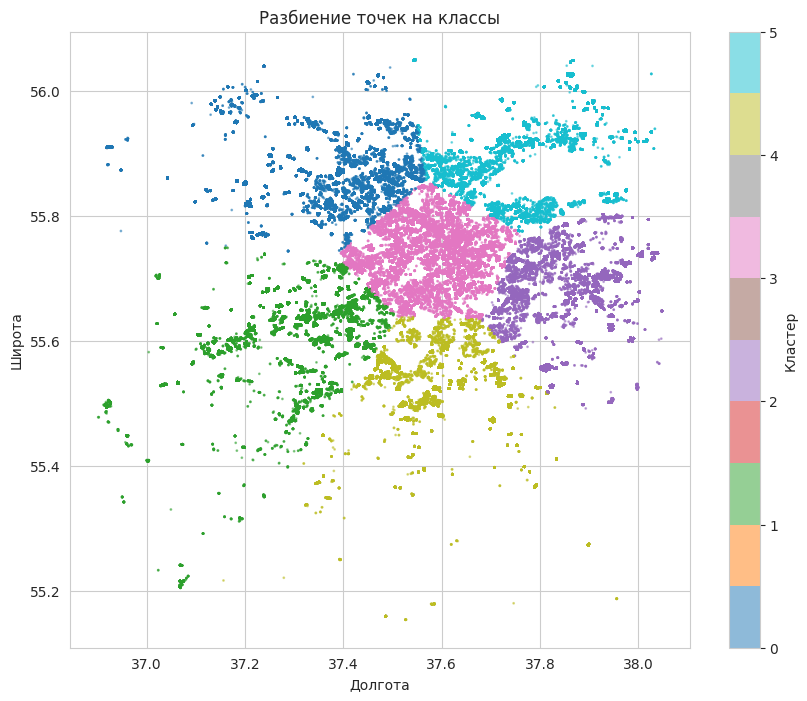

In [6]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_clean["longitude"],
    df_clean["latitude"],
    c=df_clean["cluster_zone"],
    cmap="tab10",
    s=1,
    alpha=0.5,
)
plt.colorbar(scatter, label="Кластер")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.title("Разбиение точек на классы")
plt.show()

In [7]:
# Создаём столбец и заполняем его значением по умолчанию
df["cluster_zone"] = -1

# Заполняем метками для тех строк, которые были в df_clean
df.loc[df_clean.index, "cluster_zone"] = df_clean["cluster_zone"]

# Проверяем, сколько объектов осталось без кластера
print(
    f"Объектов без кластера (из‑за пропусков координат): {(df['cluster_zone'] == -1).sum()}"
)

if "cluster_zone" not in df.columns:
    df_clean = df.dropna(subset=["longitude", "latitude"]).copy()
    coords = df_clean[["longitude", "latitude"]].values
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)

    kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
    clusters = kmeans.fit_predict(coords_scaled)
    df_clean["cluster_zone"] = clusters

    df["cluster_zone"] = -1
    df.loc[df_clean.index, "cluster_zone"] = df_clean["cluster_zone"]

Объектов без кластера (из‑за пропусков координат): 0


In [8]:
def compare_primary_secondary(primary_df, secondary_df, min_samples=10):
    area_prim = primary_df["area"].dropna()
    area_sec = secondary_df["area"].dropna()
    floor_prim = primary_df["floor"].dropna()
    floor_sec = secondary_df["floor"].dropna()

    n_area_prim = len(area_prim)
    n_area_sec = len(area_sec)
    n_floor_prim = len(floor_prim)
    n_floor_sec = len(floor_sec)

    if (n_area_prim < min_samples and n_area_sec < min_samples) and (
        n_floor_prim < min_samples and n_floor_sec < min_samples
    ):
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Наложение первички и вторички", fontsize=16)

    # ------------------ Гистограмма площади (area) ------------------
    ax = axes[0, 0]
    ax.set_title("Гистограмма площади (area)")
    ax.set_xlabel("Площадь, м²")
    ax.set_ylabel("Плотность")
    if n_area_prim >= min_samples:
        sns.histplot(
            area_prim,
            kde=True,
            stat="density",
            bins=30,
            color="blue",
            alpha=0.5,
            label=f"primary (n={n_area_prim})",
            ax=ax,
        )
    if n_area_sec >= min_samples:
        sns.histplot(
            area_sec,
            kde=True,
            stat="density",
            bins=30,
            color="orange",
            alpha=0.5,
            label=f"secondary (n={n_area_sec})",
            ax=ax,
        )
    if n_area_prim < min_samples and n_area_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ ЭФР площади ------------------
    ax = axes[0, 1]
    ax.set_title("ЭФР площади")
    ax.set_xlabel("Площадь, м²")
    ax.set_ylabel("Доля")
    if n_area_prim >= min_samples:
        sorted_vals = np.sort(area_prim)
        y = np.arange(1, n_area_prim + 1) / n_area_prim
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="blue",
            label=f"primary (n={n_area_prim})",
        )
    if n_area_sec >= min_samples:
        sorted_vals = np.sort(area_sec)
        y = np.arange(1, n_area_sec + 1) / n_area_sec
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="orange",
            label=f"secondary (n={n_area_sec})",
        )
    if n_area_prim < min_samples and n_area_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ Гистограмма этажа (floor) ------------------
    ax = axes[1, 0]
    ax.set_title("Гистрограмма этажа (floor)")
    ax.set_xlabel("Этаж")
    ax.set_ylabel("Плотность")
    if n_floor_prim >= min_samples:
        sns.histplot(
            floor_prim,
            kde=True,
            stat="density",
            bins=30,
            color="blue",
            alpha=0.5,
            label=f"primary (n={n_floor_prim})",
            ax=ax,
        )
    if n_floor_sec >= min_samples:
        sns.histplot(
            floor_sec,
            kde=True,
            stat="density",
            bins=30,
            color="orange",
            alpha=0.5,
            label=f"secondary (n={n_floor_sec})",
            ax=ax,
        )
    if n_floor_prim < min_samples and n_floor_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ ЭФР этажа ------------------
    ax = axes[1, 1]
    ax.set_title("ЭФР этажа")
    ax.set_xlabel("Этаж")
    ax.set_ylabel("Доля")
    if n_floor_prim >= min_samples:
        sorted_vals = np.sort(floor_prim)
        y = np.arange(1, n_floor_prim + 1) / n_floor_prim
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="blue",
            label=f"primary (n={n_floor_prim})",
        )
    if n_floor_sec >= min_samples:
        sorted_vals = np.sort(floor_sec)
        y = np.arange(1, n_floor_sec + 1) / n_floor_sec
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="orange",
            label=f"secondary (n={n_floor_sec})",
        )
    if n_floor_prim < min_samples and n_floor_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    plt.tight_layout()
    plt.show()

Графики ЭФР для первички и вторички с наложением:

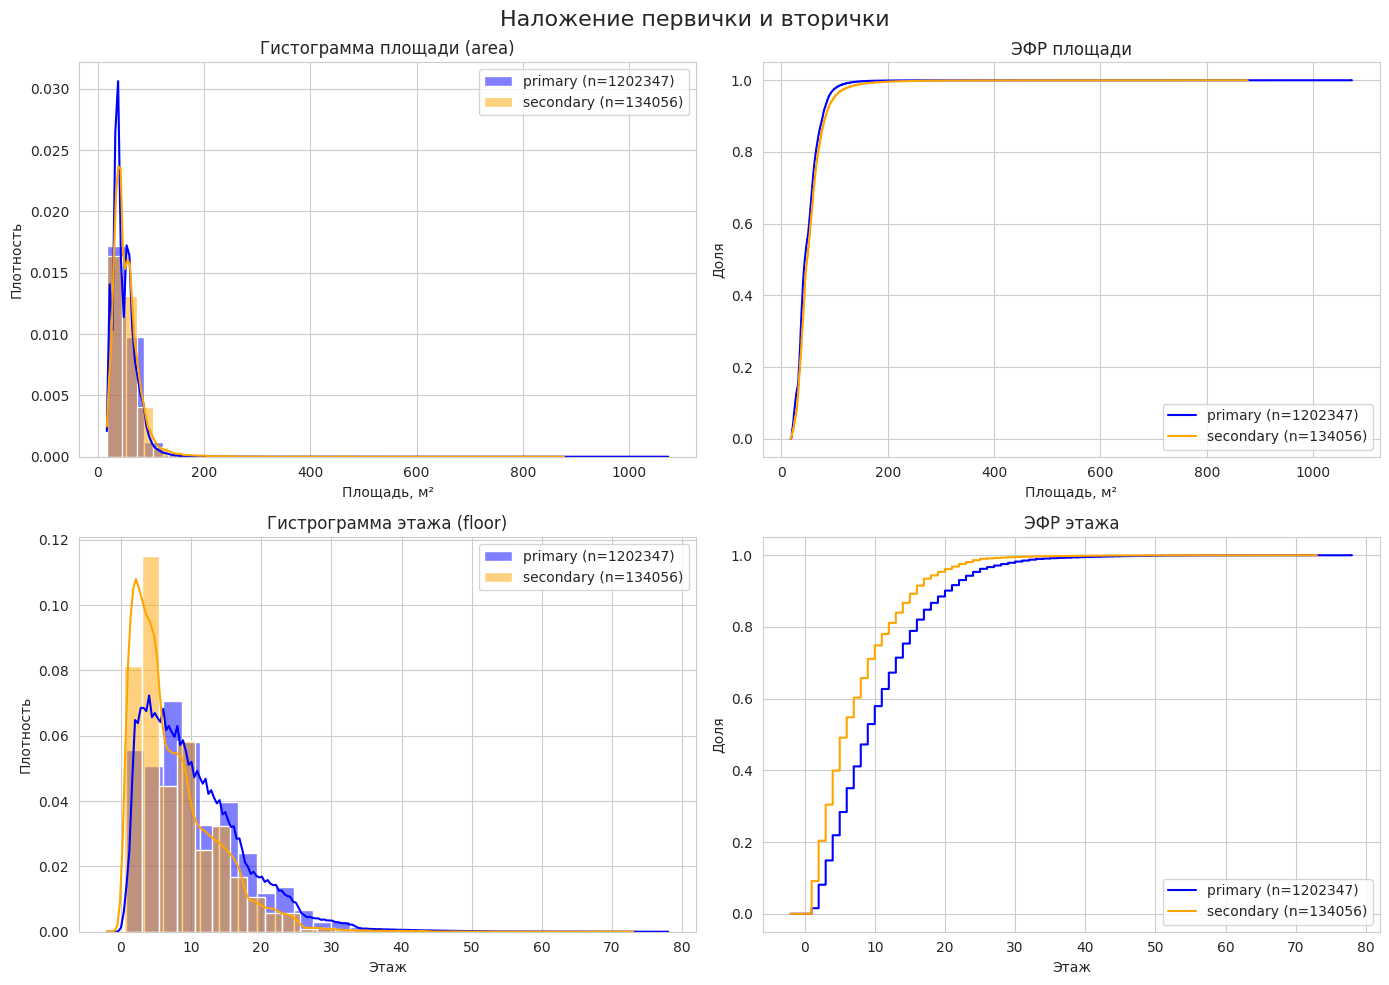

In [9]:
primary = df[df["market_type"] == "primary"]
secondary = df[df["market_type"] == "secondary"]
compare_primary_secondary(primary, secondary)

Построим ЭФР для нужных значений.

In [ ]:
def plot_group_distribution(
    group_data, group_name, columns, min_samples=10, log_columns=None, bins=30
):
    """
    Parameters
    ----------
    group_data : DataFrame - Данные группы
    group_name : str - Название группы
    columns : list of str - Список, для чего строить ЭФР и плотности
    min_samples : int, default=10 - Минимальное количество не пропущенных значений
    log_columns : list of str, optional - Колонки, для которых использовать логарифмическую шкалу
    bins : int, default=30 - Количество бинов гистограммы (для логарифмической шкалы бины строятся в лог-пространстве)
    """
    if log_columns is None:
        log_columns = []

    n_params = len(columns)
    if n_params == 0:
        print("Нет параметров для построения")
        return

    fig, axes = plt.subplots(n_params, 2, figsize=(12, 4 * n_params))
    fig.suptitle(f"Группа: {group_name}", fontsize=14)

    # Если всего один параметр, axes будет одномерным, приводим к двумерному виду
    if n_params == 1:
        axes = axes.reshape(1, -1)

    for i, col in enumerate(columns):
        vals = group_data[col].dropna()
        n_vals = len(vals)
        use_log = col in log_columns

        # --- Гистограмма ---
        ax_hist = axes[i, 0]
        if n_vals >= min_samples:
            if use_log:
                # Логарифмические бины
                logbins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), bins)
                sns.histplot(vals, bins=logbins, kde=False, ax=ax_hist, stat="density")
                ax_hist.set_xscale("log")
                title_suffix = " [log]"
            else:
                sns.histplot(vals, kde=True, ax=ax_hist, stat="density", bins=bins)
                title_suffix = ""
            ax_hist.set_title(f"{col} (n={n_vals}){title_suffix}")
            ax_hist.set_xlabel(col)
        else:
            ax_hist.text(0.5, 0.5, "No data", ha="center", va="center")
            ax_hist.set_title(col)

        # --- ЭФР ---
        ax_ecdf = axes[i, 1]
        if n_vals >= min_samples:
            sorted_vals = np.sort(vals)
            y = np.arange(1, n_vals + 1) / n_vals
            ax_ecdf.step(sorted_vals, y, where="post")
            if use_log:
                ax_ecdf.set_xscale("log")
                title_suffix = " [log]"
            else:
                title_suffix = ""
            ax_ecdf.set_title(f"ЭФР {col} (n={n_vals}){title_suffix}")
            ax_ecdf.set_xlabel(col)
            ax_ecdf.set_ylabel("Доля")
        else:
            ax_ecdf.text(0.5, 0.5, "No data", ha="center", va="center")
            ax_ecdf.set_title(f"ЭФР {col}")

    plt.tight_layout()
    plt.show()

Параметры, по которым будем проводить группировки:

In [20]:
groupings = {
    # "overall": None,
    "by_market_type": "market_type",
    "by_flat_type": "flat_type",
    "by_zone": "cluster_zone",
}

Столбцы, для которых надо построить ЭФР указываются в ячейке ниже в массиве `efr_columns=`. 

На момент создания: `efr_columns = ['floor', 'area', 'price']`.

P.S.: для столбцов, для которых нужна лог.шкала не будет построена плотность, лишь гистограмма. Так как `kde=True` не работает корректно с лог.шкалами.

Группировка: by_market_type


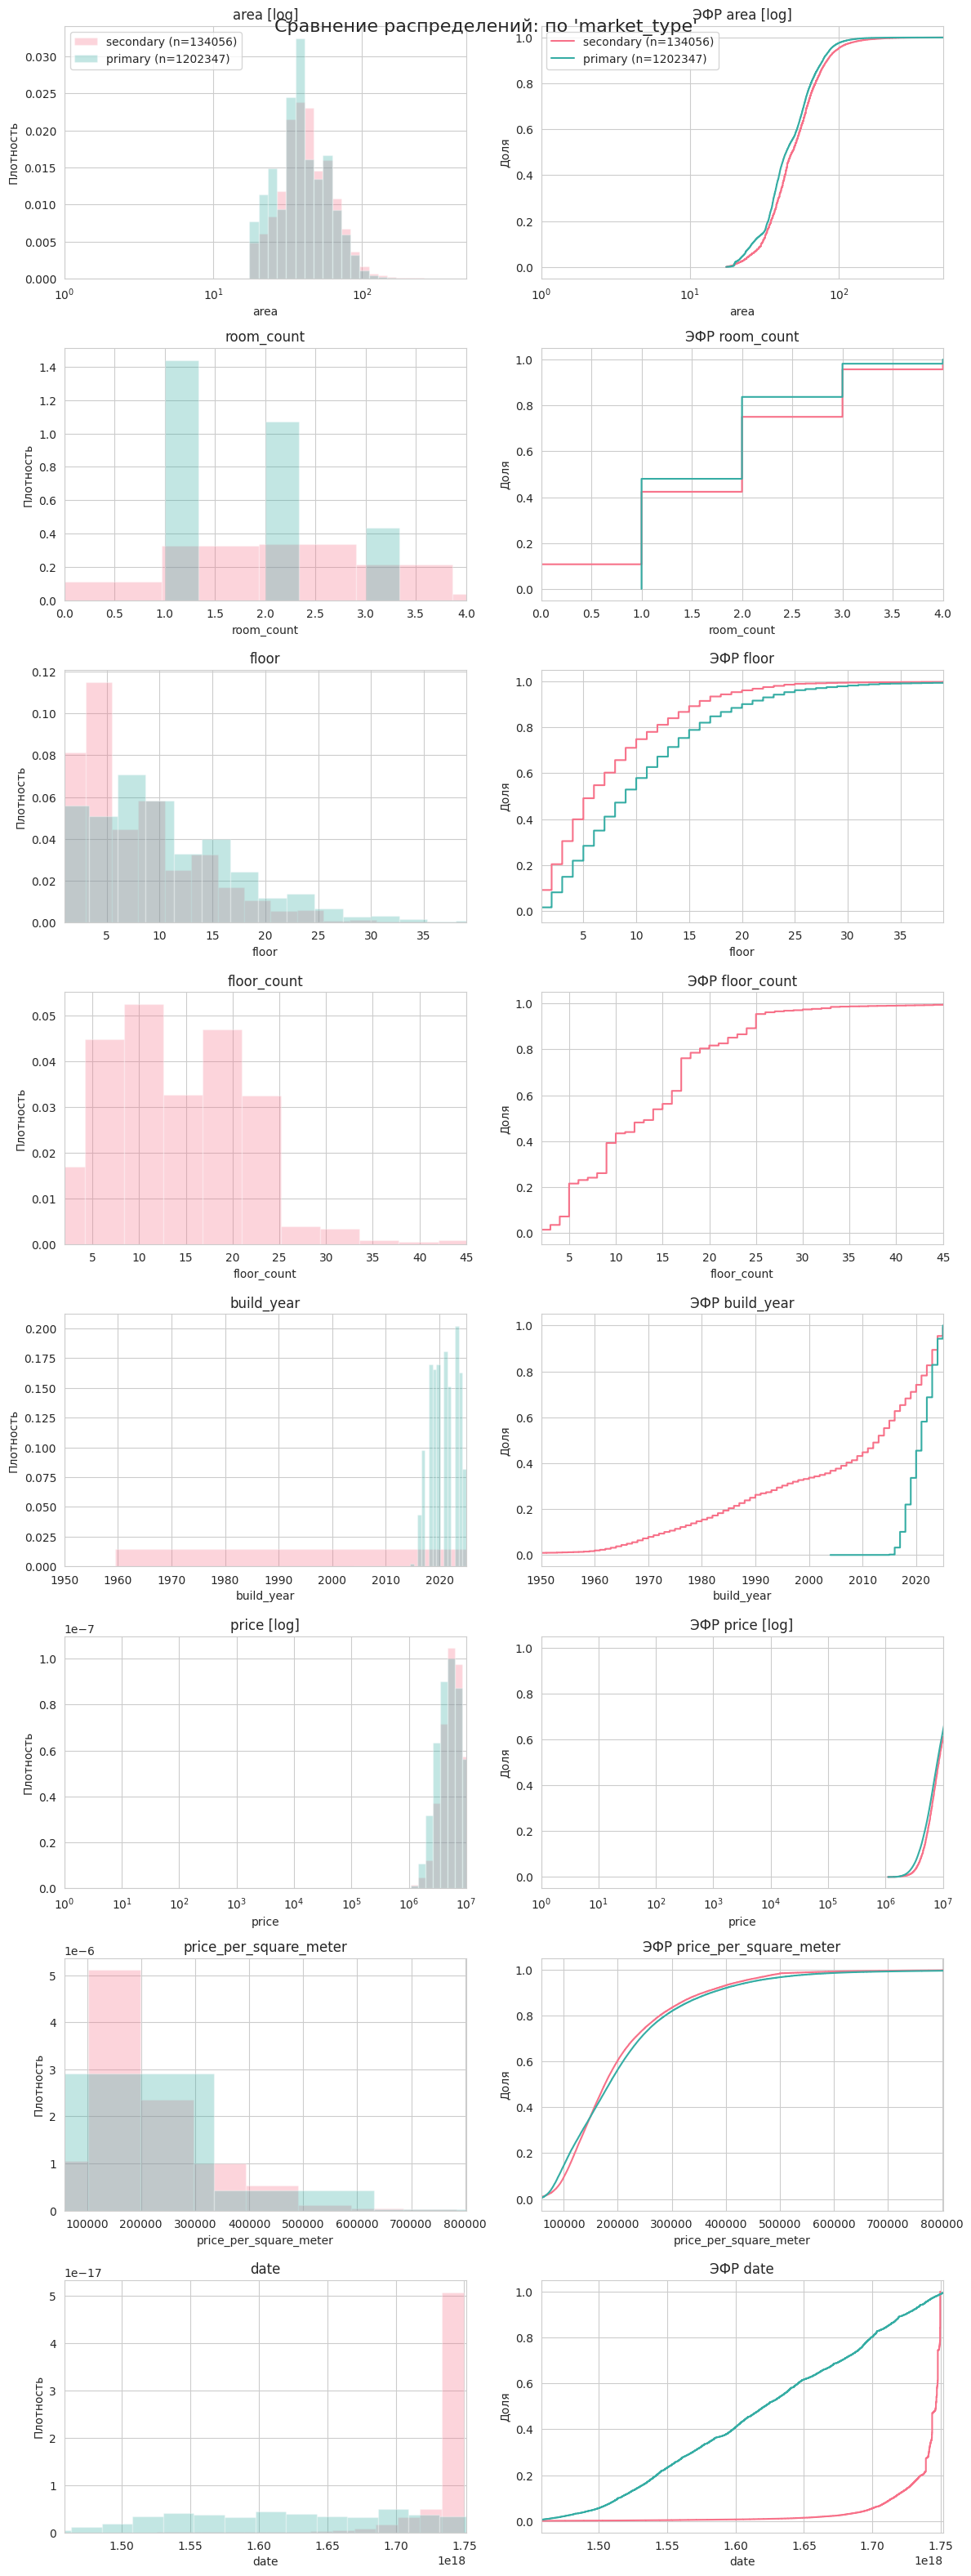

Группировка: by_flat_type


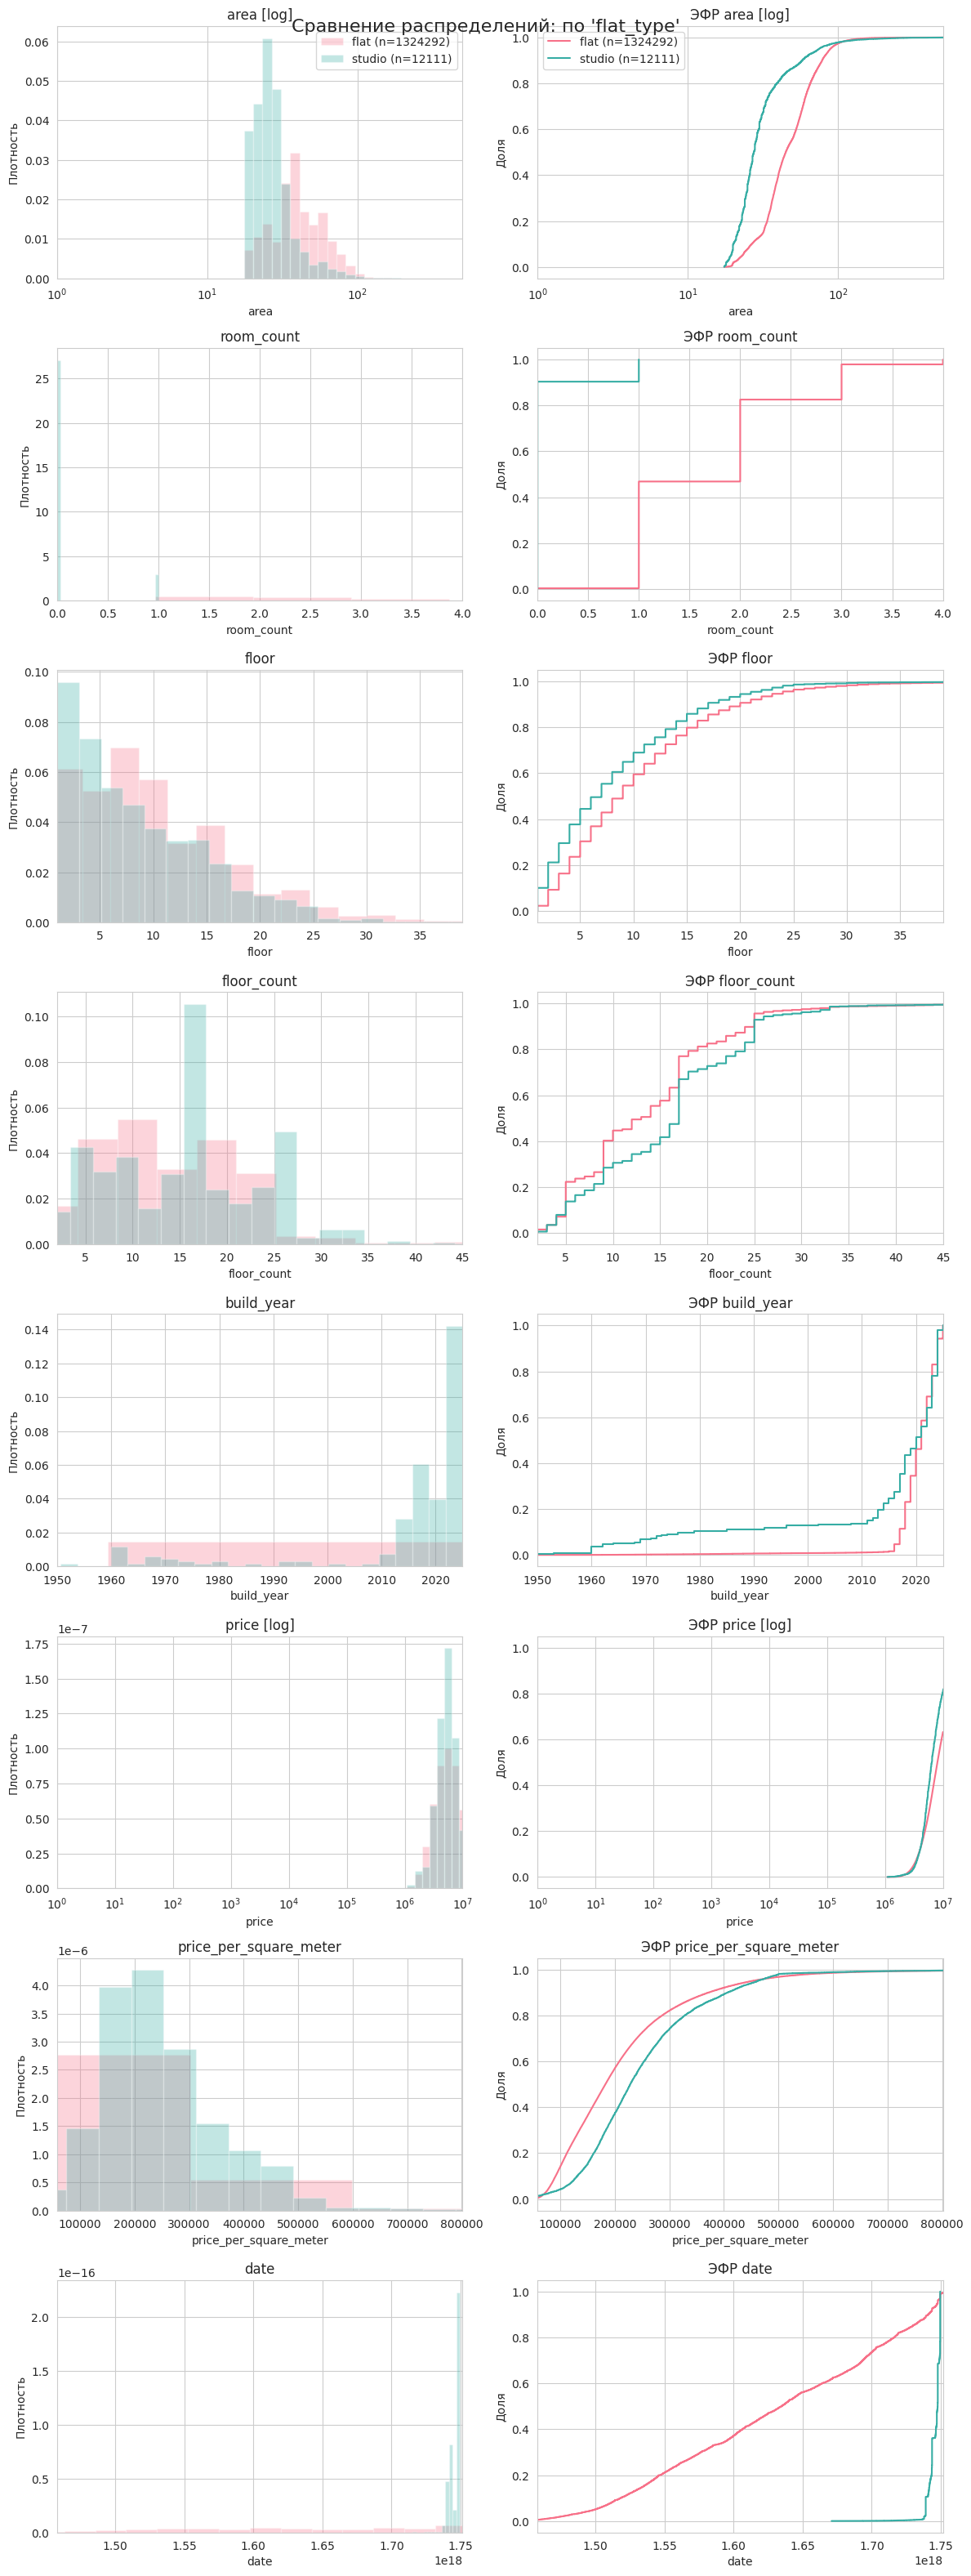

Группировка: by_zone


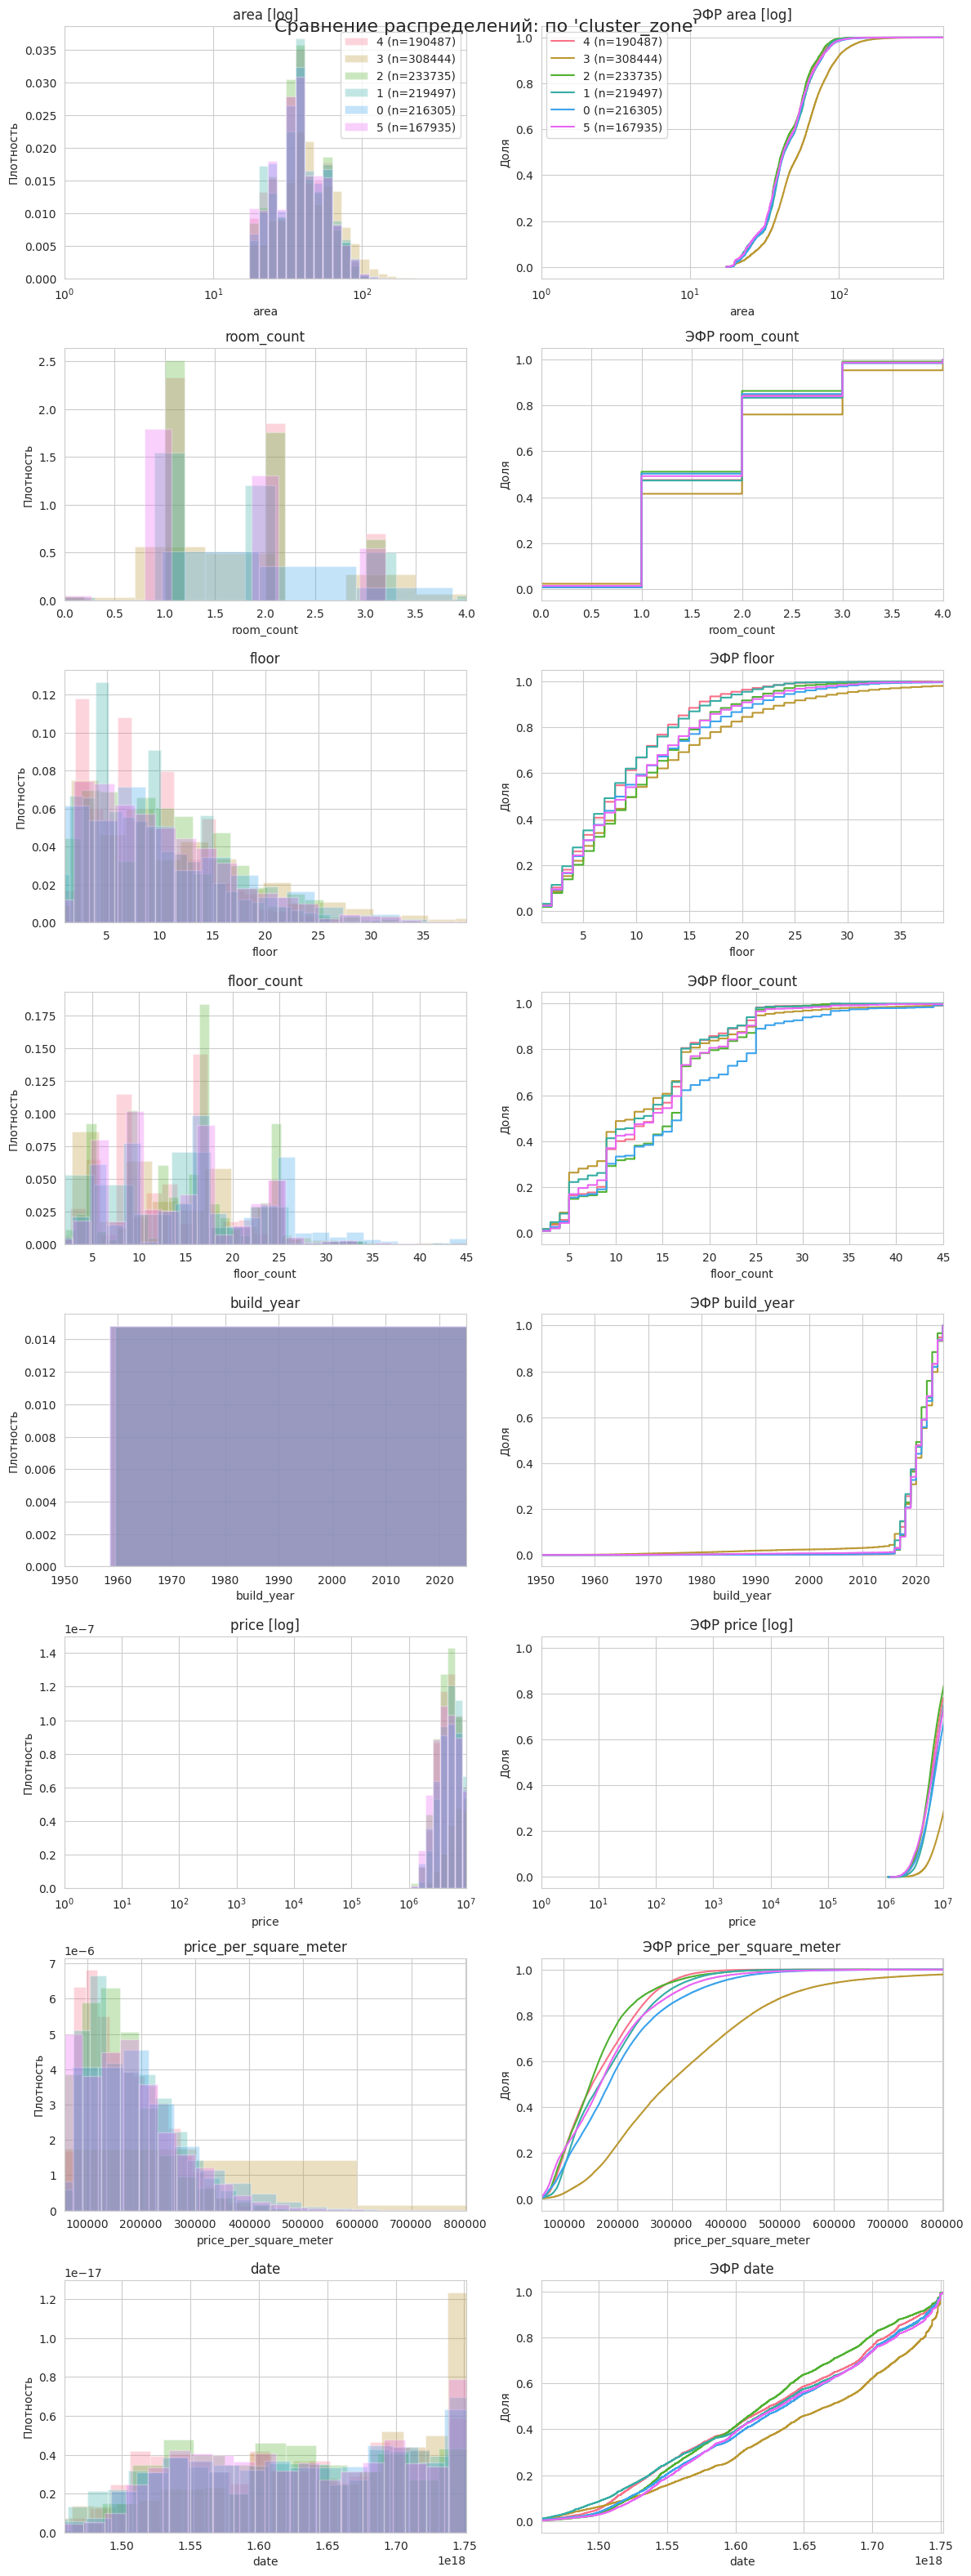

In [30]:
efr_columns = ['area', 'room_count', 'floor', 
               'floor_count', 'build_year', 'price', 'price_per_square_meter', 'date']
log_columns = ['area', 'price']


def plot_group_comparison(df, group_col, columns, log_columns=None,
                          min_samples=10, bins=30, percentile_clip=False,
                          plot_kwargs=None):
    """
    Для заданной группировки (group_col) строит на одном полотне все подгруппы.
    Если group_col is None, считается, что есть только одна группа "all".
    Для каждой колонки из columns создаются два подграфика:
    - гистограмма (или гистограмма в логарифмической шкале)
    - эмпирическая функция распределения (ЭФР)
    На каждом подграфике накладываются данные всех подгрупп.
    
    Параметры:
        percentile_clip (bool): если True, ограничить ось X по 0.5 и 99.5 перцентилям.
        plot_kwargs (dict): словарь вида {col: {'xlim': (low, high), ...}} для ручных настроек.
    """
    if log_columns is None:
        log_columns = []
    if plot_kwargs is None:
        plot_kwargs = {}
    
    # Определяем список подгрупп
    if group_col is None:
        groups = [('all', df)]
    else:
        unique_vals = df[group_col].dropna().unique()
        groups = [(val, df[df[group_col] == val]) for val in unique_vals]
    
    n_params = len(columns)
    if n_params == 0:
        print("Нет параметров для построения")
        return
    
    fig, axes = plt.subplots(n_params, 2, figsize=(12, 4 * n_params))
    if n_params == 1:
        axes = axes.reshape(1, -1)
    
    colors = sns.color_palette("husl", len(groups))
    
    for i, col in enumerate(columns):
        use_log = col in log_columns
        ax_hist = axes[i, 0]
        ax_ecdf = axes[i, 1]
        
        ax_hist.clear()
        ax_ecdf.clear()
        
        df_col_numeric = pd.to_numeric(df[col], errors='coerce')
        
        xlim = None
        if col in plot_kwargs and 'xlim' in plot_kwargs[col]:
            xlim = plot_kwargs[col]['xlim']
        elif percentile_clip:
            all_vals = df_col_numeric.dropna()
            if len(all_vals) > 0:
                low = np.percentile(all_vals, 0.5)
                high = np.percentile(all_vals, 99.5)
                xlim = (low, high)
        
        all_group_vals = []
        for _, grp_data in groups:
            vals = pd.to_numeric(grp_data[col], errors='coerce').dropna()
            if len(vals) >= min_samples:
                all_group_vals.extend(vals)
        
        if len(all_group_vals) == 0:
            ax_hist.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_ecdf.text(0.5, 0.5, "No data", ha='center', va='center')
            continue
        
        logbins = None
        if use_log:
            logbins = np.logspace(np.log10(np.min(all_group_vals)),
                                  np.log10(np.max(all_group_vals)), bins)
        
        for (label, grp_data), color in zip(groups, colors):
            vals = pd.to_numeric(grp_data[col], errors='coerce').dropna()
            n_vals = len(vals)
            if n_vals < min_samples:
                continue
            
            if use_log:
                ax_hist.hist(vals, bins=logbins, density=True, alpha=0.3,
                             color=color, label=f"{label} (n={n_vals})")
                ax_hist.set_xscale("log")
            else:
                ax_hist.hist(vals, bins=bins, density=True, alpha=0.3,
                             color=color, label=f"{label} (n={n_vals})")
            
            sorted_vals = np.sort(vals)
            y = np.arange(1, n_vals + 1) / n_vals
            ax_ecdf.step(sorted_vals, y, where="post", color=color,
                         label=f"{label} (n={n_vals})")
            if use_log:
                ax_ecdf.set_xscale("log")
        
        if xlim is not None:
            ax_hist.set_xlim(xlim)
            ax_ecdf.set_xlim(xlim)
        
        ax_hist.set_xlabel(col)
        ax_hist.set_ylabel("Плотность")
        ax_ecdf.set_xlabel(col)
        ax_ecdf.set_ylabel("Доля")
        
        title_suffix = " [log]" if use_log else ""
        ax_hist.set_title(f"{col}{title_suffix}")
        ax_ecdf.set_title(f"ЭФР {col}{title_suffix}")
        
        if i == 0:
            ax_hist.legend()
            ax_ecdf.legend()
        else:
            if ax_hist.get_legend():
                ax_hist.get_legend().remove()
            if ax_ecdf.get_legend():
                ax_ecdf.get_legend().remove()
    
    group_name = "все данные" if group_col is None else f"по '{group_col}'"
    fig.suptitle(f"Сравнение распределений: {group_name}", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_kwargs = {
    'build_year': {'xlim': (1950, 2025)},
    'area': {'xlim': (1, 500)},
    'price': {'xlim': (1, 1e7)}
}


for group_name, group_col in groupings.items():
    print(f"Группировка: {group_name}")
    plot_group_comparison(df, group_col, efr_columns,
                          log_columns=log_columns,
                          percentile_clip=True,
                          plot_kwargs=plot_kwargs)

Графики ЭФР и плотности представлены в ячейке выше.